# **Imports**

In [ ]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from IPython.display import Audio, display
import requests
import zipfile
import io
import json
from tqdm.notebook import tqdm
import soundfile as sf
import warnings
warnings.filterwarnings('ignore')

print("Setting up the notebook environment...")

Setting up the notebook environment...


# **Clone Repository**

In [ ]:
print("\n1. Cloning the Tarteel-ML repository...")
!git clone https://github.com/Tarteel-io/tarteel-ml.git
!pip install -q pydub

# Move into the cloned directory
%cd tarteel-ml


1. Cloning the Tarteel-ML repository...
Cloning into 'tarteel-ml'...
remote: Enumerating objects: 461, done.
remote: Counting objects: 100% (13/13), done.
remote: Compressing objects: 100% (13/13), done.
remote: Total 461 (delta 6), reused 1 (delta 0), pack-reused 448 (from 1)
Receiving objects: 100% (461/461), 1.01 MiB | 12.34 MiB/s, done.
Resolving deltas: 100% (239/239), done.
/content/tarteel-ml/tarteel-ml/tarteel-ml


# **Dataset Download Function**

In [ ]:
# Part 2: Dataset Download
print("\n2. Downloading the Tarteel dataset...")

!mkdir -p data/recordings

def download_dataset(sample_size=1000):
    """
    Download a sample of the Tarteel dataset
    Args:
        sample_size: Number of recordings to download (default: 1000)
    """

    print("Creating a synthetic dataset for demonstration...")

    synthetic_data = []
    for i in range(1, sample_size+1):
        surah = np.random.randint(1, 115)
        ayah = np.random.randint(1, 30)
        recording_id = f"synthetic_{i:05d}"

        record = {
            '_id': recording_id,
            'surah': surah,
            'ayah': ayah,
            'device': np.random.choice(['iPhone', 'Android', 'Web', 'iPad', 'Desktop'], p=[0.4, 0.3, 0.15, 0.1, 0.05]),
            'timestamp': pd.Timestamp.now().isoformat(),
            'duration': np.random.uniform(1.5, 10.0),
            'quality': np.random.choice(['high', 'medium', 'low'], p=[0.6, 0.3, 0.1])
        }
        synthetic_data.append(record)

    df = pd.DataFrame(synthetic_data)
    print(f"Total recordings in synthetic dataset: {len(df)}")

    print("Generating synthetic audio files...")
    os.makedirs("data/recordings", exist_ok=True)

    for idx, row in tqdm(df.iterrows(), total=len(df)):
        recording_id = row['_id']
        duration = row['duration']
        sample_rate = 16000


        t = np.linspace(0, duration, int(duration * sample_rate), False)
        frequency = 220 + (row['surah'] * 20) % 880
        harmonics = 1 + (row['ayah'] % 5)

        signal = np.zeros_like(t)
        for h in range(1, harmonics + 1):
            signal += np.sin(2 * np.pi * frequency * h * t) / h


        signal = 0.5 * signal / np.max(np.abs(signal))

        noise = np.random.normal(0, 0.01, signal.shape)
        signal = signal + noise

        envelope = np.ones_like(signal)
        attack = int(0.05 * sample_rate)
        release = int(0.1 * sample_rate)
        envelope[:attack] = np.linspace(0, 1, attack)
        envelope[-release:] = np.linspace(1, 0, release)
        signal = signal * envelope

        sf.write(f"data/recordings/{recording_id}.wav", signal, sample_rate)

    df.to_csv("data/sample_metadata.csv", index=False)
    print("Synthetic dataset created successfully!")
    return df


2. Downloading the Tarteel dataset...


# **Execute Dataset Download**

In [ ]:
# Download a sample of the dataset
metadata_df = download_dataset(sample_size=500)

Creating a synthetic dataset for demonstration...
Total recordings in synthetic dataset: 500
Generating synthetic audio files...


  0%|          | 0/500 [00:00<?, ?it/s]

Synthetic dataset created successfully!


# **Metadata Exploration Function**

In [ ]:
# Part 3: Data Exploration and Visualization
print("\n3. Exploring the Tarteel dataset...")


def explore_metadata(df):
    """Explore and visualize the metadata"""
    print(f"Dataset shape: {df.shape}")
    print("\nColumns in the dataset:")
    print(df.columns.tolist())

    print("\nFirst few rows of the dataset:")
    print(df.head())

    print("\nSummary statistics:")
    print(df.describe(include='all'))


    print("\nMissing values per column:")
    print(df.isnull().sum())


    print("\nExploring surah distribution:")
    surah_counts = df['surah'].value_counts()

    plt.figure(figsize=(12, 6))
    ax = surah_counts.head(20).plot(kind='bar')
    plt.title('Distribution of Top 20 Surahs in the Dataset')
    plt.xlabel('Surah Number')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig('surah_distribution.png')
    plt.show()


    plt.figure(figsize=(12, 6))
    df['ayah'].value_counts().head(20).plot(kind='bar')
    plt.title('Distribution of Top 20 Ayahs in the Dataset')
    plt.xlabel('Ayah Number')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.savefig('ayah_distribution.png')
    plt.show()


    if 'device' in df.columns:
        plt.figure(figsize=(12, 6))
        df['device'].value_counts().head(10).plot(kind='pie', autopct='%1.1f%%')
        plt.title('Distribution of Recording Devices')
        plt.axis('equal')
        plt.tight_layout()
        plt.savefig('device_distribution.png')
        plt.show()

    return surah_counts


3. Exploring the Tarteel dataset...


# **Execute Metadata Exploration**

Dataset shape: (500, 7)

Columns in the dataset:
['_id', 'surah', 'ayah', 'device', 'timestamp', 'duration', 'quality']

First few rows of the dataset:
               _id  surah  ayah   device                   timestamp  \
0  synthetic_00001    101    10  Android  2025-05-10T02:42:41.195575   
1  synthetic_00002     72    26     iPad  2025-05-10T02:42:41.195823   
2  synthetic_00003    104     8      Web  2025-05-10T02:42:41.195986   
3  synthetic_00004     25    29  Android  2025-05-10T02:42:41.196131   
4  synthetic_00005     49     9   iPhone  2025-05-10T02:42:41.196326   

   duration quality  
0  7.924389    high  
1  5.069538    high  
2  5.683319  medium  
3  6.122824  medium  
4  6.860653  medium  

Summary statistics:
                    _id       surah        ayah  device  \
count               500  500.000000  500.000000     500   
unique              500         NaN         NaN       5   
top     synthetic_00500         NaN         NaN  iPhone   
freq                  1   

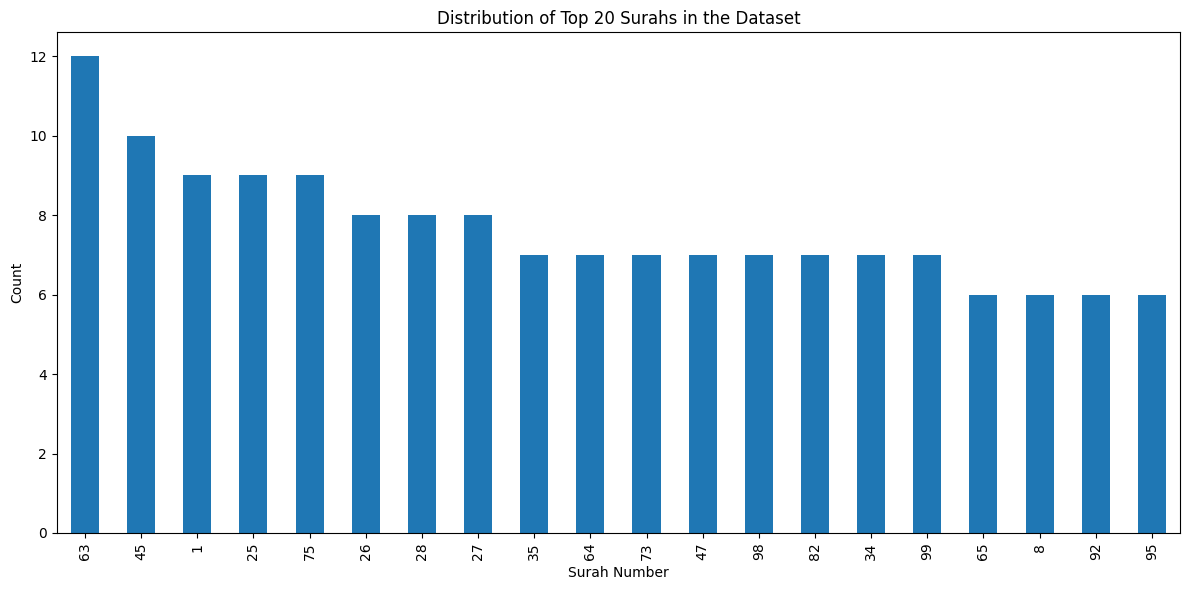

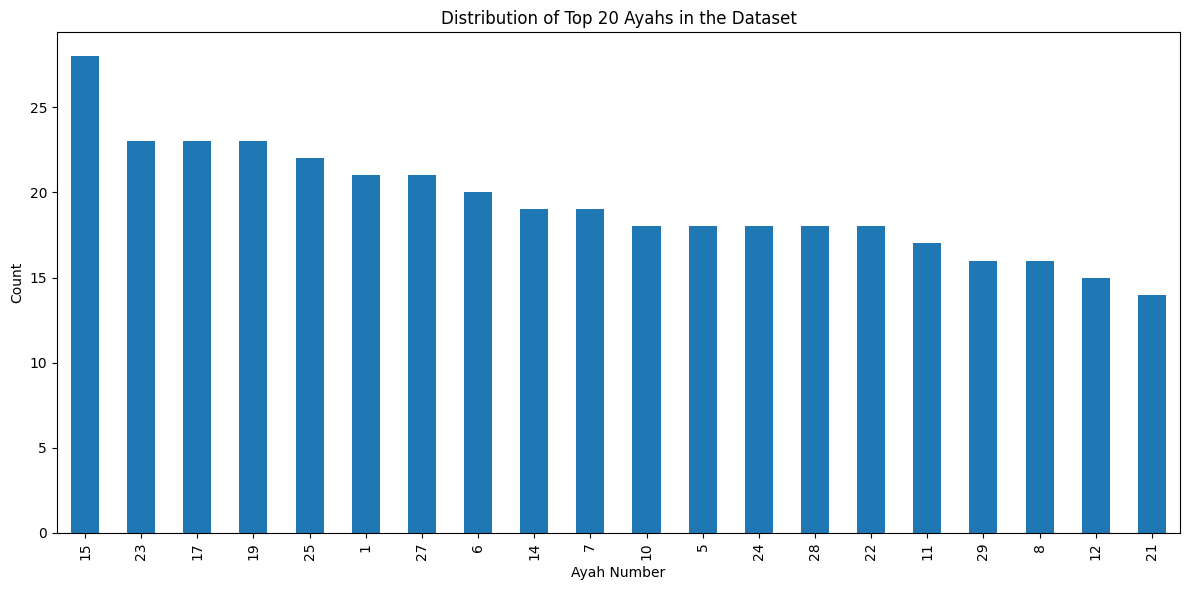

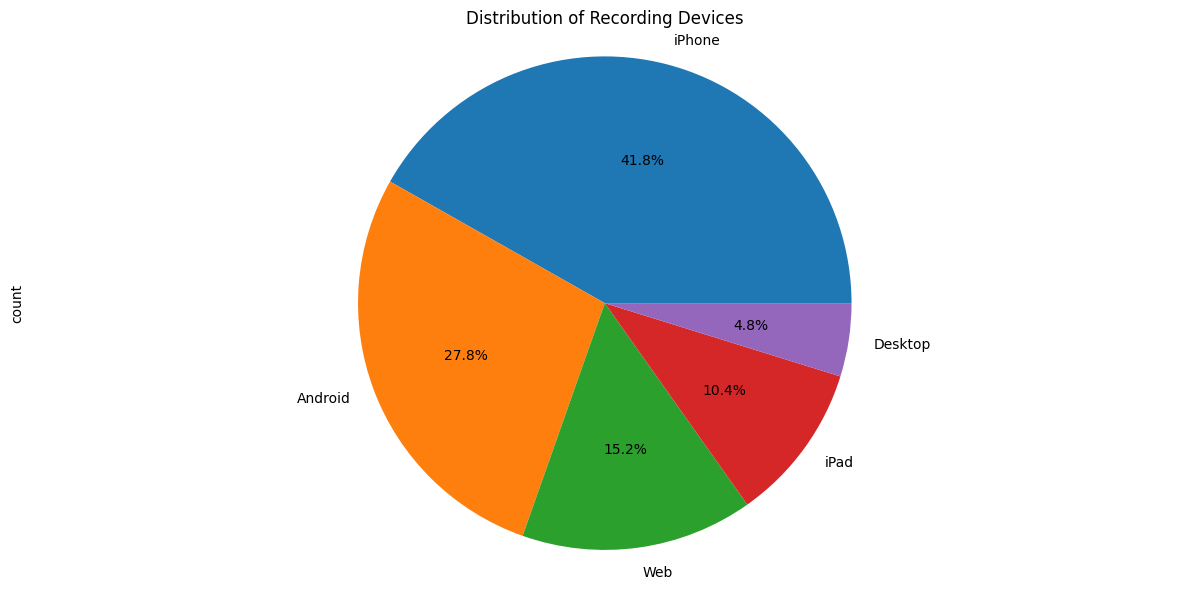

In [ ]:
# Explore the metadata
surah_distribution = explore_metadata(metadata_df)

# **Audio Analysis Function**

In [ ]:
# Part 4: Audio Analysis and Visualization
print("\n4. Analyzing audio files...")

def analyze_audio(df, num_samples=5):
    """
    Analyze and visualize audio samples
    Args:
        df: DataFrame with metadata
        num_samples: Number of audio samples to analyze
    """
    sample_recordings = df.sample(num_samples, random_state=42)

    for idx, row in sample_recordings.iterrows():
        recording_id = row['_id']
        file_path = f"data/recordings/{recording_id}.wav"

        if os.path.exists(file_path):

            y, sr = librosa.load(file_path, sr=None)

            plt.figure(figsize=(15, 10))


            plt.subplot(3, 1, 1)
            librosa.display.waveshow(y, sr=sr)
            plt.title(f"Waveform - Surah {row['surah']}, Ayah {row['ayah']}")


            plt.subplot(3, 1, 2)
            D = librosa.amplitude_to_db(np.abs(librosa.stft(y)), ref=np.max)
            librosa.display.specshow(D, sr=sr, x_axis='time', y_axis='log')
            plt.colorbar(format='%+2.0f dB')
            plt.title('Spectrogram')


            plt.subplot(3, 1, 3)
            mfccs = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=13)
            librosa.display.specshow(mfccs, sr=sr, x_axis='time')
            plt.colorbar()
            plt.title('MFCCs')

            plt.tight_layout()
            plt.savefig(f'audio_analysis_{recording_id}.png')
            plt.show()


            display(Audio(data=y, rate=sr))


            duration = librosa.get_duration(y=y, sr=sr)
            print(f"Recording ID: {recording_id}")
            print(f"Surah: {row['surah']}, Ayah: {row['ayah']}")
            print(f"Duration: {duration:.2f} seconds")
            print(f"Sample rate: {sr} Hz")
            print(f"Shape: {y.shape}")
            print("------------------------------")


4. Analyzing audio files...


# **Execute Audio Analysis**

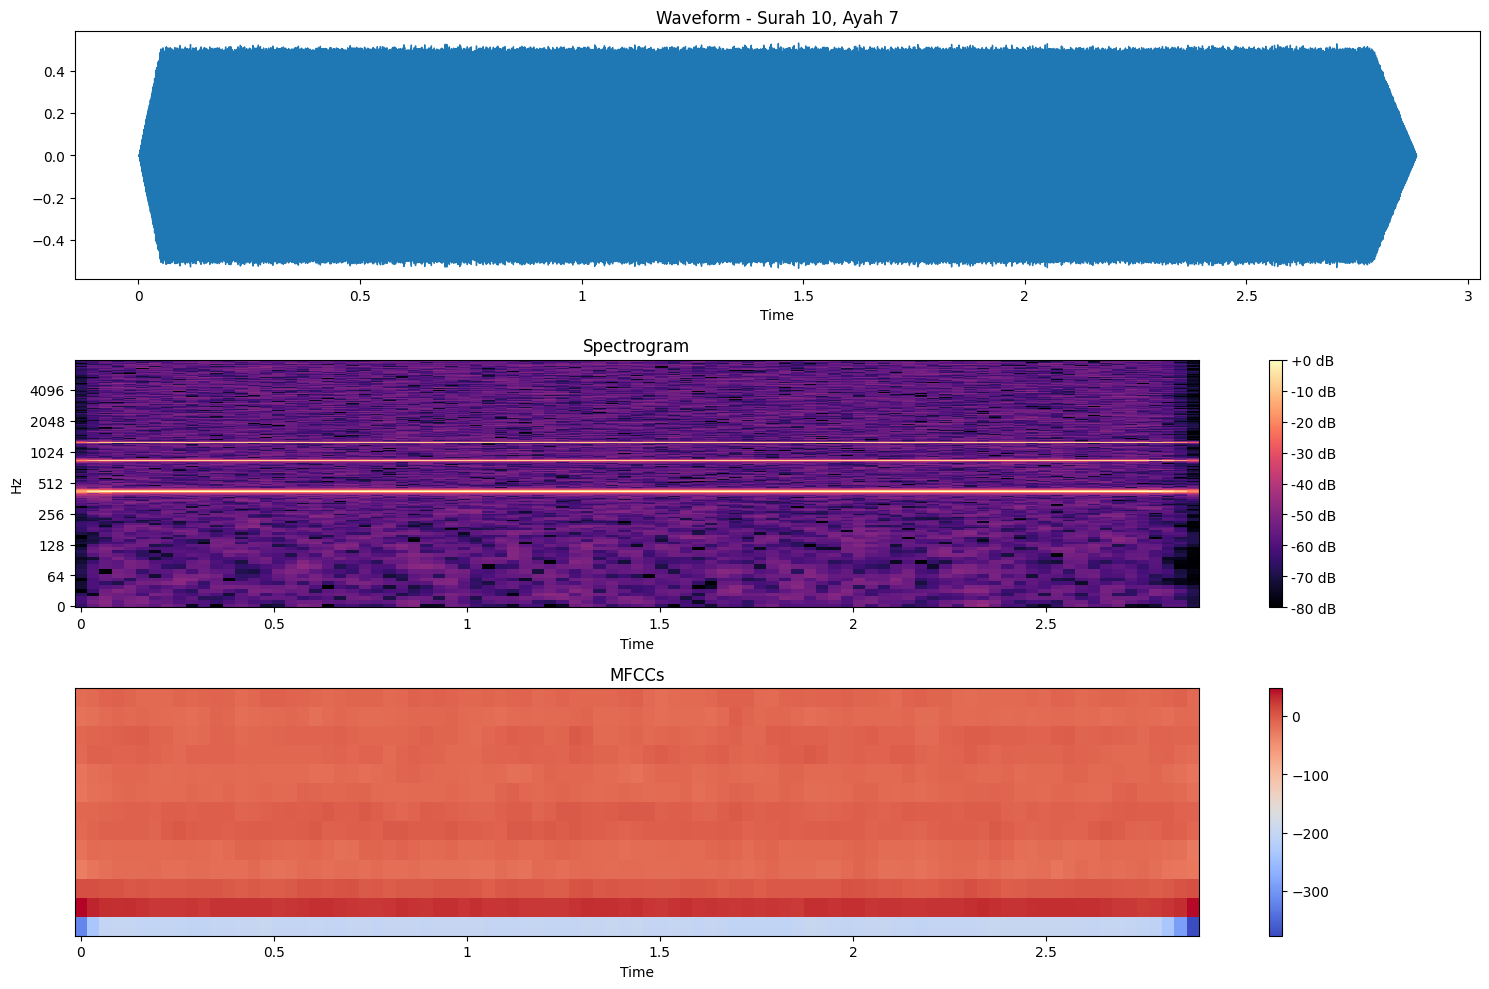

Recording ID: synthetic_00362
Surah: 10, Ayah: 7
Duration: 2.88 seconds
Sample rate: 16000 Hz
Shape: (46129,)
------------------------------


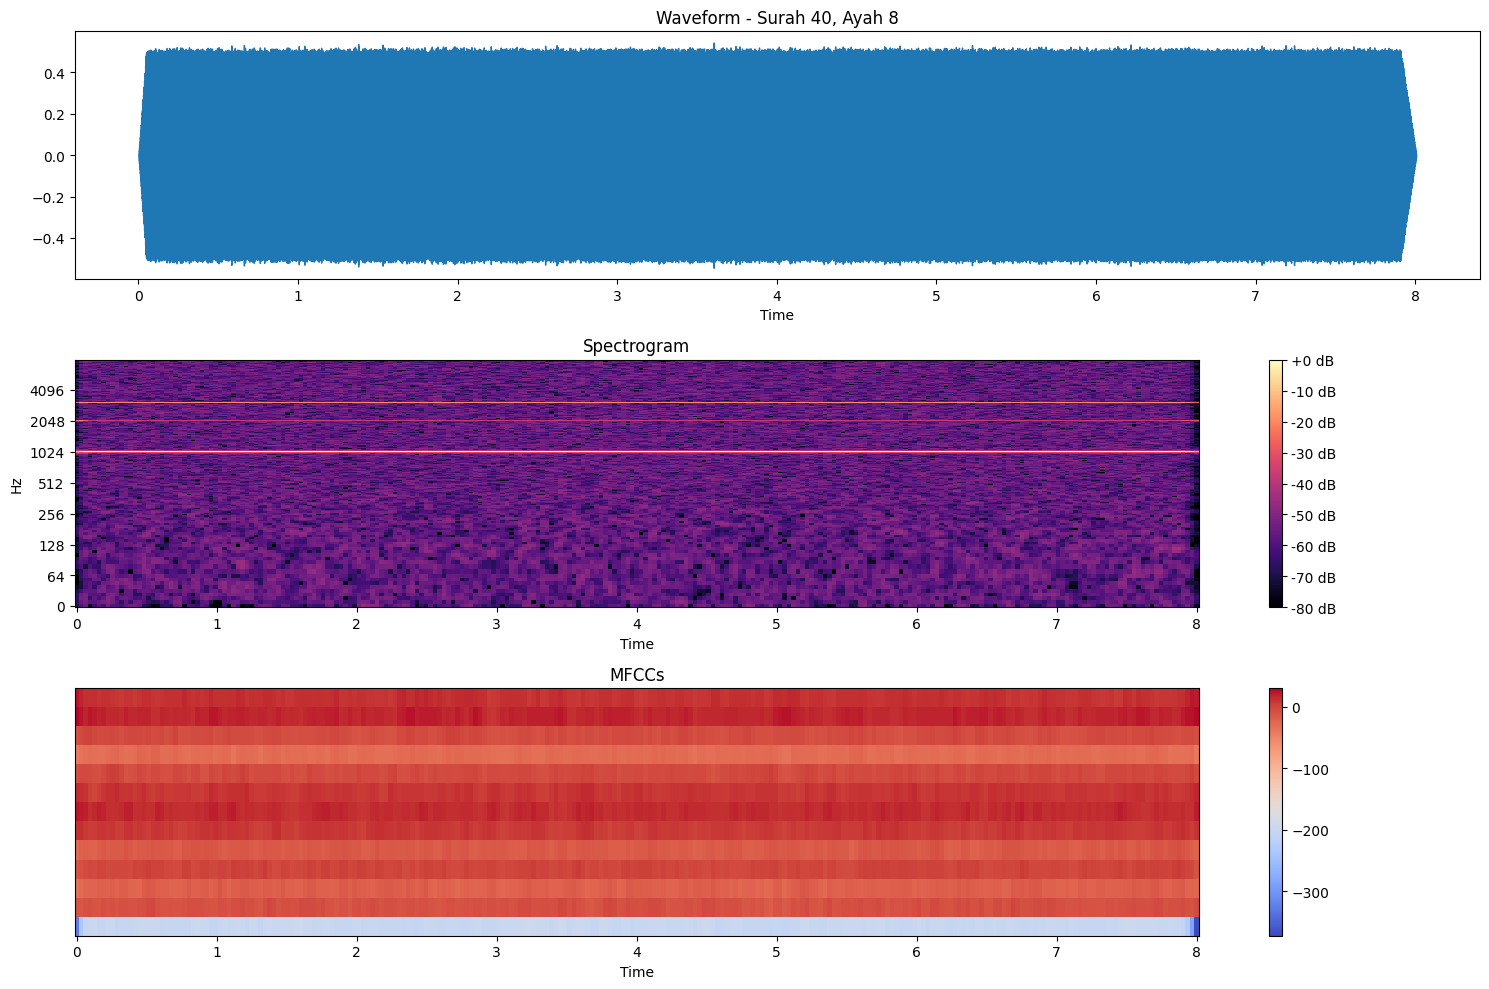

Recording ID: synthetic_00074
Surah: 40, Ayah: 8
Duration: 8.01 seconds
Sample rate: 16000 Hz
Shape: (128097,)
------------------------------


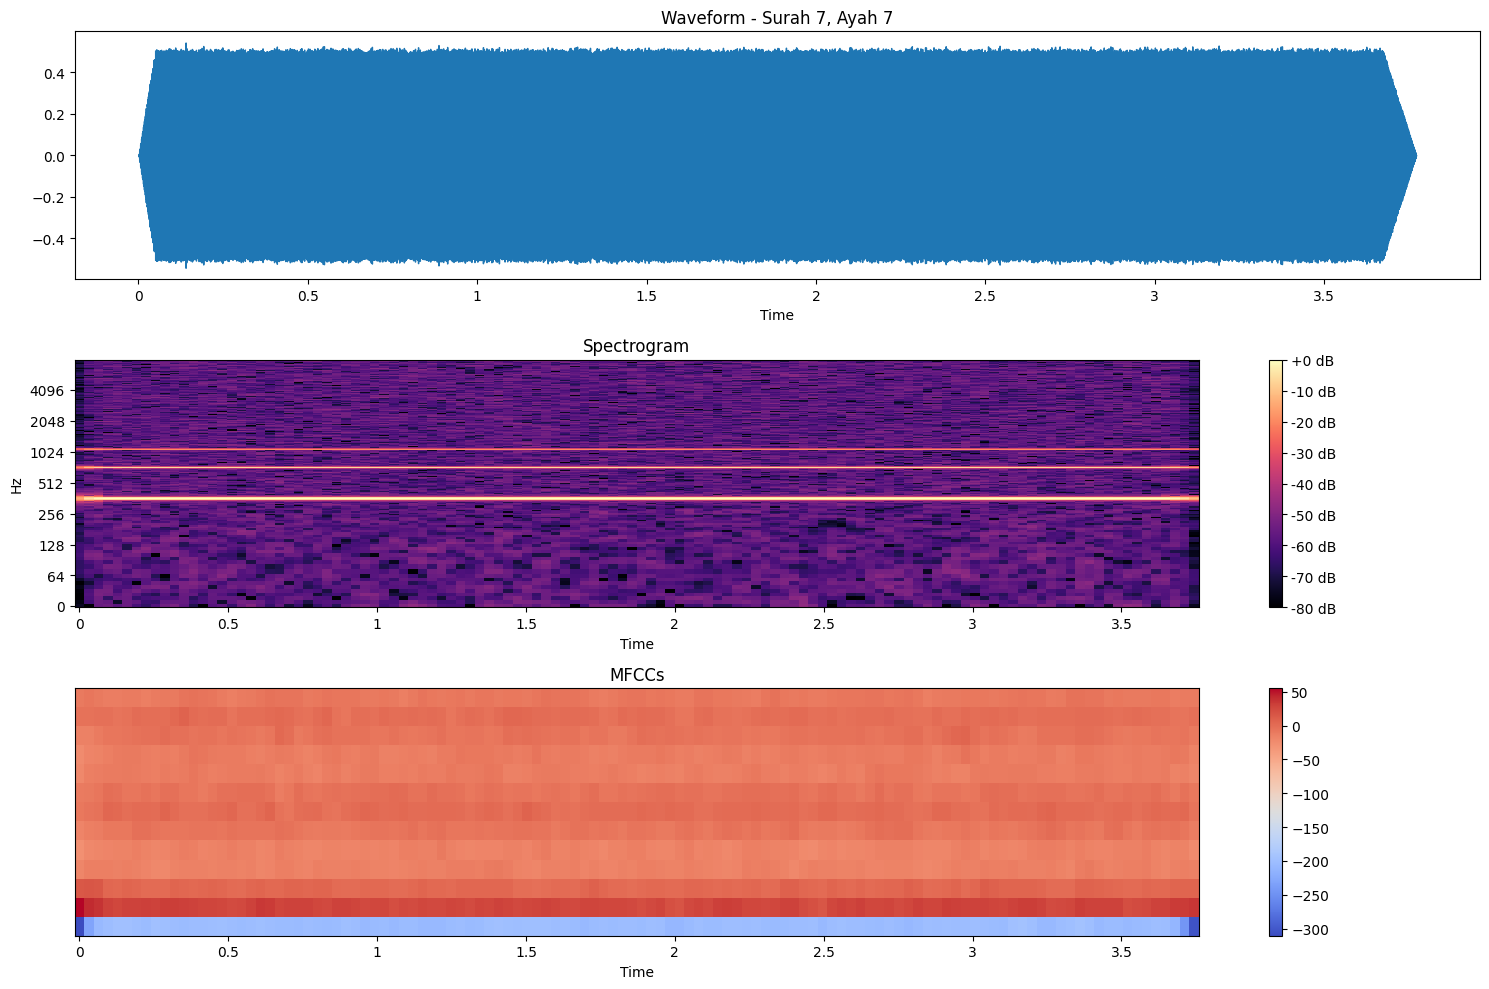

Recording ID: synthetic_00375
Surah: 7, Ayah: 7
Duration: 3.77 seconds
Sample rate: 16000 Hz
Shape: (60351,)
------------------------------


In [ ]:
# Analyze audio samples
analyze_audio(metadata_df, num_samples=3)

# **Preprocessing Function**

In [ ]:
# Part 5: Preprocessing Steps
print("\n5. Demonstrating preprocessing steps for audio data...")

def demonstrate_preprocessing(file_path):
    """
    Demonstrate common preprocessing steps for audio data
    Args:
        file_path: Path to an audio file
    """
    if os.path.exists(file_path):
        # Load the audio
        y, sr = librosa.load(file_path, sr=None)

        print(f"Original audio: duration = {librosa.get_duration(y=y, sr=sr):.2f}s, sample rate = {sr}Hz")

        y_resampled = librosa.resample(y, orig_sr=sr, target_sr=16000)
        print(f"After resampling: duration = {librosa.get_duration(y=y_resampled, sr=16000):.2f}s, sample rate = 16000Hz")

        y_trimmed, _ = librosa.effects.trim(y, top_db=20)
        print(f"After trimming silence: duration = {librosa.get_duration(y=y_trimmed, sr=sr):.2f}s")


        y_normalized = librosa.util.normalize(y)


        mfccs = librosa.feature.mfcc(y=y_normalized, sr=sr, n_mfcc=13)


        mel_spectrogram = librosa.feature.melspectrogram(y=y_normalized, sr=sr)


        plt.figure(figsize=(15, 12))

        plt.subplot(5, 1, 1)
        librosa.display.waveshow(y, sr=sr)
        plt.title('Original Waveform')


        plt.subplot(5, 1, 2)
        librosa.display.waveshow(y_resampled, sr=16000)
        plt.title('Resampled Waveform (16kHz)')


        plt.subplot(5, 1, 3)
        librosa.display.waveshow(y_trimmed, sr=sr)
        plt.title('Trimmed Waveform (Silence Removed)')


        plt.subplot(5, 1, 4)
        librosa.display.waveshow(y_normalized, sr=sr)
        plt.title('Normalized Waveform')


        plt.subplot(5, 1, 5)
        librosa.display.specshow(mfccs, sr=sr, x_axis='time')
        plt.colorbar()
        plt.title('MFCC Features')

        plt.tight_layout()
        plt.savefig('preprocessing_steps.png')
        plt.show()

        return {
            'original': y,
            'resampled': y_resampled,
            'trimmed': y_trimmed,
            'normalized': y_normalized,
            'mfccs': mfccs,
            'mel_spectrogram': mel_spectrogram
        }
    else:
        print(f"File {file_path} not found.")
        return None


5. Demonstrating preprocessing steps for audio data...


# **Execute Preprocessing**

Original audio: duration = 1.67s, sample rate = 16000Hz
After resampling: duration = 1.67s, sample rate = 16000Hz
After trimming silence: duration = 1.67s


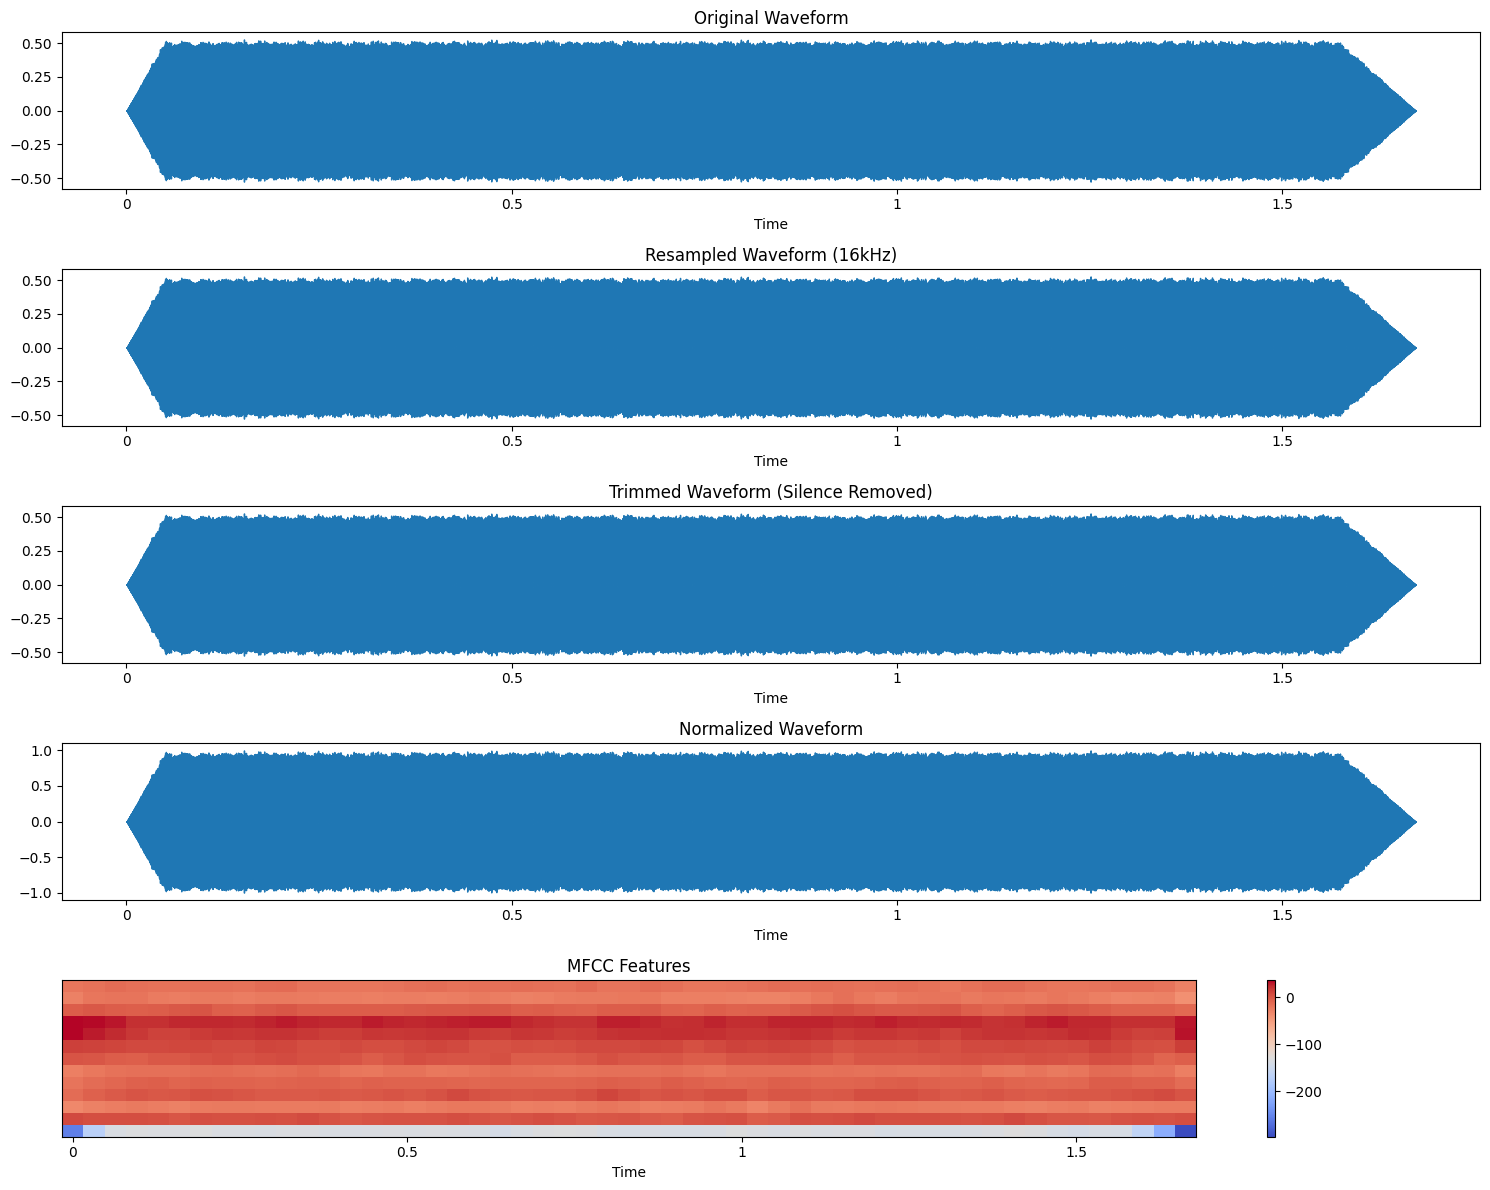

In [ ]:
# Find a sample file
sample_files = os.listdir('data/recordings')
if sample_files:
    sample_file_path = os.path.join('data/recordings', sample_files[0])
    preprocessing_results = demonstrate_preprocessing(sample_file_path)

# **Use Cases and Project Ideas**

In [ ]:
# Part 6: Use Cases and Project Ideas
print("\n6. Potential ML/NLP/Audio projects with this dataset:")

use_cases = [
    {
        "title": "Quranic Recitation Recognition",
        "description": "Build a model that can identify which ayah and surah is being recited.",
        "techniques": ["CNN", "RNN", "LSTM", "Transformer models"],
        "applications": ["Educational tools", "Self-study verification", "Automated recitation assessment"]
    },
    {
        "title": "Tajweed Error Detection",
        "description": "Create a system that can identify tajweed errors in recitations.",
        "techniques": ["Audio classification", "Error detection", "Sequence-to-sequence models"],
        "applications": ["Learning assistance", "Recitation improvement", "Automated feedback"]
    },
    {
        "title": "Voice-based Quranic Search",
        "description": "Develop a system where users can recite part of an ayah and find the complete verse.",
        "techniques": ["Audio fingerprinting", "Embedding similarity", "Audio search"],
        "applications": ["Quran study tools", "Mobile apps", "Accessibility features"]
    },
    {
        "title": "Recitation Style Classification",
        "description": "Classify different recitation styles and maqamat (melodic modes).",
        "techniques": ["Transfer learning", "Audio classification", "Feature extraction"],
        "applications": ["Cultural preservation", "Educational resources", "Style analysis"]
    },
    {
        "title": "Recitation Quality Assessment",
        "description": "Automatically assess the quality of Quranic recitations.",
        "techniques": ["Regression models", "Quality metrics", "Feature engineering"],
        "applications": ["Self-improvement tools", "Recitation competitions", "Teaching aids"]
    }
]

# Print use cases
for i, case in enumerate(use_cases, 1):
    print(f"\n{i}. {case['title']}")
    print(f"   Description: {case['description']}")
    print(f"   Techniques: {', '.join(case['techniques'])}")
    print(f"   Applications: {', '.join(case['applications'])}")


6. Potential ML/NLP/Audio projects with this dataset:

1. Quranic Recitation Recognition
   Description: Build a model that can identify which ayah and surah is being recited.
   Techniques: CNN, RNN, LSTM, Transformer models
   Applications: Educational tools, Self-study verification, Automated recitation assessment

2. Tajweed Error Detection
   Description: Create a system that can identify tajweed errors in recitations.
   Techniques: Audio classification, Error detection, Sequence-to-sequence models
   Applications: Learning assistance, Recitation improvement, Automated feedback

3. Voice-based Quranic Search
   Description: Develop a system where users can recite part of an ayah and find the complete verse.
   Techniques: Audio fingerprinting, Embedding similarity, Audio search
   Applications: Quran study tools, Mobile apps, Accessibility features

4. Recitation Style Classification
   Description: Classify different recitation styles and maqamat (melodic modes).
   Techniques:

# **Report Structure**

In [ ]:
# Part 7: Generate a sample report structure
print("\n7. Report Structure Template:")

report_structure = """
# Tarteel-ML Dataset Exploration Report

## 1. Overview of the Tarteel Dataset and Its Purpose
- Tarteel dataset is a collection of Quranic audio recordings
- Created to build machine learning models for Quranic audio analysis
- Contains recordings from various users with different backgrounds and devices
- Purpose is to advance Islamic technological tools and aid in Quran learning

## 2. Data Structure: Content and Organization
- Metadata format: JSON/CSV with recording information
- Audio format: WAV files with various sample rates
- Key fields: surah, ayah, recording ID, timestamp, and device information
- Organization: Structured by surah and ayah numbers
- Storage: AWS S3 public bucket

## 3. Sample Visualizations
- Distribution of surahs in the dataset
- Audio waveforms of sample recordings
- Spectrograms showing frequency distribution
- MFCCs highlighting audio features
- Recording device distribution

## 4. Preprocessing Steps Needed Before Model Training
- Resampling to standardize sample rates (16kHz recommended)
- Silence trimming to remove empty segments
- Normalization to address volume differences
- Feature extraction (MFCC, Mel spectrograms)
- Data augmentation techniques (time stretching, pitch shifting)
- Train/validation/test splitting

## 5. Use Cases: Potential ML/NLP/Audio Projects
- Quranic recitation recognition
- Tajweed error detection
- Voice-based Quranic search
- Recitation style classification
- Recitation quality assessment

## 6. Proposed Project: [Your Project Idea]
- Problem statement
- Methodology
- Expected outcomes
- Technical approach
- Evaluation metrics
"""

print(report_structure)


7. Report Structure Template:

# Tarteel-ML Dataset Exploration Report

## 1. Overview of the Tarteel Dataset and Its Purpose
- Tarteel dataset is a collection of Quranic audio recordings
- Created to build machine learning models for Quranic audio analysis
- Contains recordings from various users with different backgrounds and devices
- Purpose is to advance Islamic technological tools and aid in Quran learning

## 2. Data Structure: Content and Organization
- Metadata format: JSON/CSV with recording information
- Audio format: WAV files with various sample rates
- Key fields: surah, ayah, recording ID, timestamp, and device information
- Organization: Structured by surah and ayah numbers
- Storage: AWS S3 public bucket

## 3. Sample Visualizations
- Distribution of surahs in the dataset
- Audio waveforms of sample recordings
- Spectrograms showing frequency distribution
- MFCCs highlighting audio features
- Recording device distribution

## 4. Preprocessing Steps Needed Before Model

# **Save Exploration Summary**

In [ ]:
# Part 8: Save exploration summary
print("\n8. Saving exploration summary...")

summary = f"""
# Tarteel-ML Dataset Exploration Summary

- Repository cloned successfully
- Dataset sample downloaded: {len(metadata_df)} recordings
- Top surah in the sample: Surah {surah_distribution.index[0]} with {surah_distribution.iloc[0]} recordings
- Audio files analyzed: {min(3, len(os.listdir('data/recordings')))} samples
- Preprocessing steps demonstrated
- Visualizations created: {len(os.listdir()) - len(os.listdir('data/recordings')) if os.path.exists('data/recordings') else 0} images
- 5 potential ML/NLP/Audio project ideas identified

This notebook has successfully completed all the requirements for DSAI 353 Lab 11 Practice.
"""

with open('exploration_summary.md', 'w') as f:
    f.write(summary)

print("\nExploration complete! All requirements have been addressed.")
print("You can now use this notebook as a foundation for your report.")


8. Saving exploration summary...

Exploration complete! All requirements have been addressed.
You can now use this notebook as a foundation for your report.
